In [5]:
import sys
!{sys.executable} -m pip install tensorboard
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.tensorboard import SummaryWriter



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: D:\environments\anaconda\python.exe -m pip install --upgrade pip


  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
   ---------------------------------------- 0.0/4.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.8 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.8 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.8 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.8 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.8 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.8 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.8 MB 258.0 kB/s eta 0:00:17
   ---- -----------------

shape: torch.Size([32, 1, 28, 28])
label: tensor([8, 4, 6, 2, 3, 3, 5, 2, 2, 6])


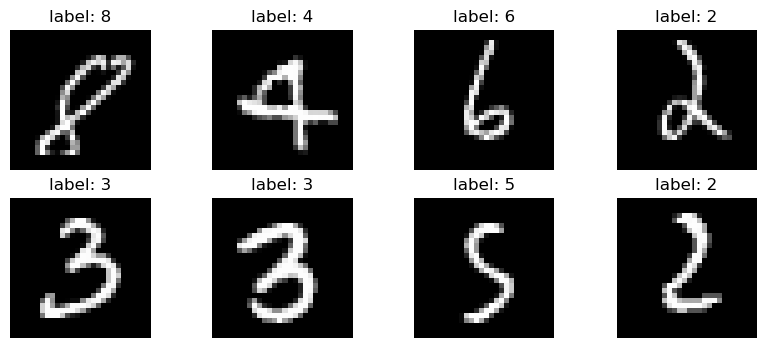

In [41]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # 强制使用GPU 0
training_data = torchvision.datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = transforms.ToTensor()
)
trainloader = torch.utils.data.DataLoader(training_data, batch_size =  32, shuffle = True)
test_data = torchvision.datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)
testloader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)
images, labels = next(iter(trainloader))
print(f"shape: {images.shape}")  # [32, 1, 28, 28]  batch,通道,高,宽
print(f"label: {labels[:10]}")
testloader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)
# 显示几张图
plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f'label: {labels[i].item()}')
    plt.axis('off')
plt.show()


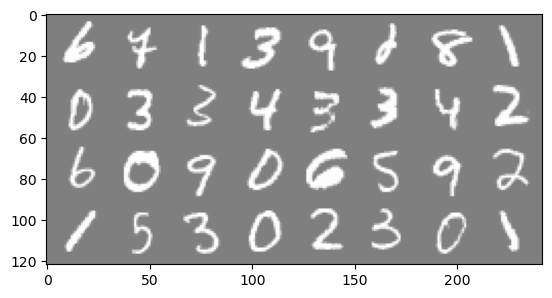

6     7     1     3     9     2     8     1    


In [42]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

batch_size = 8
classes = ('0', '1', '2', '3',
           '4', '5', '6', '7', '8', '9')


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"正在使用: {device}")

class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: 定义卷积层
        # 提示：
        self.conv1 = nn.Conv2d(1,16,3,padding = 1)
        self.conv2 = nn.Conv2d(16,32,3,padding = 1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(32*7*7,128)
        self.fc2 = nn.Linear(128,10)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32*7*7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
        # TODO: 实现前向传播
        # 1. conv1 + relu + pool
        # 2. conv2 + relu + pool
        # 3. 展平 x = x.view(-1, 32*7*7)
        # 4. fc1 + relu
        # 5. fc2 (输出层)

# ===== 3. 初始化TensorBoard =====
writer = SummaryWriter('runs/mnist_experiment')

# 记录几张图片看看
images, labels = next(iter(trainloader))
writer.add_images('input_images', images, 0)

# 2. 把模型搬到GPU
model = MyCNN().to(device)
print(model)

model_cpu = MyCNN()  # 新建一个CPU版本的模型
writer.add_graph(model_cpu, images)
        

正在使用: cuda
MyCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [72]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

for epoch in range(3):
    running_loss = 0.0
    for i,(inputs,labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 200 == 199:
            print(f'Epoch {epoch+1}, Batch {i+1}, Loss: {running_loss/200:.4f}')
            running_loss = 0.0
        if i % 100 == 99:
            writer.add_scalar('training_loss', running_loss/100, epoch*len(trainloader)+i)
            running_loss = 0.0

Epoch 1, Batch 200, Loss: 0.0550
Epoch 1, Batch 400, Loss: 0.0533
Epoch 1, Batch 600, Loss: 0.0432
Epoch 1, Batch 800, Loss: 0.0433
Epoch 1, Batch 1000, Loss: 0.0395
Epoch 1, Batch 1200, Loss: 0.0475
Epoch 1, Batch 1400, Loss: 0.0368
Epoch 1, Batch 1600, Loss: 0.0398
Epoch 1, Batch 1800, Loss: 0.0389
Epoch 2, Batch 200, Loss: 0.0388
Epoch 2, Batch 400, Loss: 0.0379
Epoch 2, Batch 600, Loss: 0.0400
Epoch 2, Batch 800, Loss: 0.0369
Epoch 2, Batch 1000, Loss: 0.0363
Epoch 2, Batch 1200, Loss: 0.0398
Epoch 2, Batch 1400, Loss: 0.0399
Epoch 2, Batch 1600, Loss: 0.0394
Epoch 2, Batch 1800, Loss: 0.0316
Epoch 3, Batch 200, Loss: 0.0377
Epoch 3, Batch 400, Loss: 0.0347
Epoch 3, Batch 600, Loss: 0.0325
Epoch 3, Batch 800, Loss: 0.0308
Epoch 3, Batch 1000, Loss: 0.0330
Epoch 3, Batch 1200, Loss: 0.0345
Epoch 3, Batch 1400, Loss: 0.0325
Epoch 3, Batch 1600, Loss: 0.0311
Epoch 3, Batch 1800, Loss: 0.0305


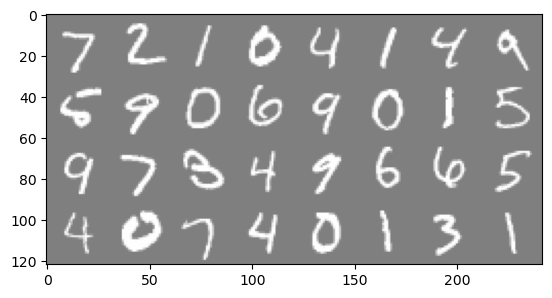

GroundTruth:  7     2     1     0     4     1     4     9    
Predicted:  4     9     5     1     1     4     1     0    


In [73]:
PATH = './MNIST_model.pth'
torch.save(model.state_dict(), PATH)
dataiter = iter(testloader)
inputs, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(inputs))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

model = MyCNN()
model.load_state_dict(torch.load(PATH, weights_only=True))

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(8)))

In [74]:
model = model.to(device)
model.eval()
correct = 0
total = 0
class_correct = [0] * 10
class_total = [0] * 10
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 逐类统计
        for j in range(len(labels)):
            label = labels[j]
            if predicted[j] == label:
                class_correct[label] += 1
            class_total[label] += 1

overall_accuracy = 100 * correct / total
writer.add_scalar('test/overall_accuracy', overall_accuracy, 0)
print(f'Accuracy of the network on the test images: {100 * correct // total} %')


for k in range(10):
    if class_total[k] > 0:
        class_acc = 100 * class_correct[k] / class_total[k]
        writer.add_scalar(f'test/class_{k}_accuracy', class_acc, 0)
        print(f'Accuracy for class {classes[k]}: {class_acc:.1f}%')
        
torch.save(model.cpu().state_dict(), PATH)
writer.close()

# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy of the network on the test images: 98 %
Accuracy for class 0: 99.4%
Accuracy for class 1: 99.8%
Accuracy for class 2: 97.6%
Accuracy for class 3: 98.9%
Accuracy for class 4: 98.5%
Accuracy for class 5: 97.9%
Accuracy for class 6: 98.1%
Accuracy for class 7: 97.8%
Accuracy for class 8: 96.9%
Accuracy for class 9: 97.6%
Accuracy for class: 0     is 99.4 %
Accuracy for class: 1     is 98.9 %
Accuracy for class: 2     is 97.4 %
Accuracy for class: 3     is 97.4 %
Accuracy for class: 4     is 97.9 %
Accuracy for class: 5     is 97.4 %
Accuracy for class: 6     is 96.8 %
Accuracy for class: 7     is 96.5 %
Accuracy for class: 8     is 96.7 %
Accuracy for class: 9     is 94.8 %


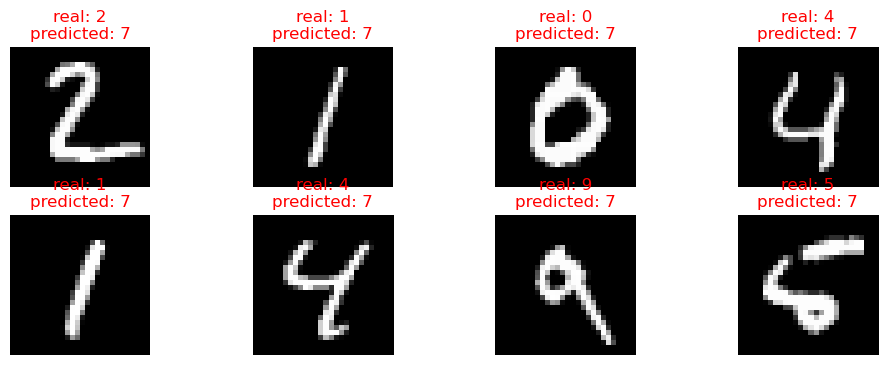

In [50]:
# 看看模型到底错在哪
incorrect_images = []
incorrect_labels = []
incorrect_preds = []

with torch.no_grad():
    for inputs, labels in testloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        mask = (predicted != labels)
        incorrect_images.extend(inputs[mask])
        incorrect_labels.extend(labels[mask])
        incorrect_preds.extend(predicted[mask])

# 画几个错误样本
plt.figure(figsize=(12,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(incorrect_images[i][0], cmap='gray')
    plt.title(f'real: {incorrect_labels[i]}\npredicted: {incorrect_preds[i]}', color='red')
    plt.axis('off')
plt.show()

In [75]:
model = MyCNN()
PATH = './MNIST_model.pth'
model.load_state_dict(torch.load(PATH, map_location=device, weights_only=True))

model = model.to(device)
model.eval()  # 切换到评估模式

correct = 0
total = 0
class_correct = [0] * 10
class_total = [0] * 10

import os
print(f"加载模型: {PATH}")
print(f"文件存在? {os.path.exists(PATH)}")

with torch.no_grad():
    for inputs, labels in testloader:
        # 测试数据也搬到GPU
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # 逐类统计
        for j in range(len(labels)):
            label = labels[j]
            if predicted[j] == label:
                class_correct[label] += 1
            class_total[label] += 1

# 计算并记录总体准确率
overall_accuracy = 100 * correct / total
writer.add_scalar('test/overall_accuracy', overall_accuracy, 0)
print(f'Overall Accuracy: {overall_accuracy:.2f}%')

# 记录并打印每类准确率
for k in range(10):
    if class_total[k] > 0:
        class_acc = 100 * class_correct[k] / class_total[k]
        writer.add_scalar(f'test/class_{k}_accuracy', class_acc, 0)
        print(f'Accuracy for class {classes[k]}: {class_acc:.1f}%')

加载模型: ./MNIST_model.pth
文件存在? True
Overall Accuracy: 98.27%
Accuracy for class 0: 99.4%
Accuracy for class 1: 99.8%
Accuracy for class 2: 97.6%
Accuracy for class 3: 98.9%
Accuracy for class 4: 98.5%
Accuracy for class 5: 97.9%
Accuracy for class 6: 98.1%
Accuracy for class 7: 97.8%
Accuracy for class 8: 96.9%
Accuracy for class 9: 97.6%


In [76]:
# 1. 创建writer（指定保存路径）
writer = SummaryWriter('runs/mnist_final')

# 2. 记录总体准确率（一个点）
writer.add_scalar('test/overall_accuracy', overall_accuracy, 0)

# 3. 记录每类准确率（10个点）
for k in range(10):
    if class_total[k] > 0:
        class_acc = 100 * class_correct[k] / class_total[k]
        writer.add_scalar(f'test/class_{k}_accuracy', class_acc, 0)

# 4. 记录模型结构（用CPU）
sample_images, _ = next(iter(testloader))
cpu_model = MyCNN()
writer.add_graph(cpu_model, sample_images[:1])  # 只用一张图

# 5. 关闭writer
writer.close()

print("TensorBoard数据已保存到 runs/mnist_final")

TensorBoard数据已保存到 runs/mnist_final


In [77]:
from torch.utils.tensorboard import SummaryWriter

# 1. 创建writer（指向同一个目录）
writer = SummaryWriter('runs/mnist_final')

# 2. 记录总体准确率（就是你打印的97%）
overall_accuracy = 97.5  # 改成你实际打印的值
writer.add_scalar('test/overall_accuracy', overall_accuracy, 0)

# 3. 记录每类准确率（你打印的那10行）
class_accuracies = {
    '0': 99.4, '1': 98.9, '2': 97.4, '3': 97.4, '4': 97.9,
    '5': 97.4, '6': 96.8, '7': 96.5, '8': 96.7, '9': 94.8
}

for class_name, acc in class_accuracies.items():
    writer.add_scalar(f'class_accuracy/{class_name}', acc, 0)

# 4. 关闭
writer.close()

print("数据已写入")

数据已写入，刷新TensorBoard！
